# 05b — RAG, Approach B: link everything except the eval batches

*Approach B: plain dense retrieval.* One dense index over the **entire corpus** (`rag_corpus.csv` = all loans except the evaluation batches). For each evaluation loan, retrieve the **top-`K_PRECEDENTS` nearest precedents** by cosine similarity of their content embeddings and inject them as labelled evidence — a classic kNN / retrieval-augmented few-shot setup.

No Semantic IDs, no staging: the whole corpus is a single flat index. This is the simpler counterpart to Approach A, and the contrast between them is the point.

Compared against a **no-RAG LLM** baseline and the **XGBoost** baseline on the same evaluation loans. Evaluation runs on **two batches** — `robustness_batch` (validation) **and** `tuning_sample` — reported per batch and pooled (200 loans, ~24 defaults). The held-out `test_batch` is reserved for Phase 4.

## Setup & config

The first cell pins OpenMP to a single thread, because torch (via sentence-transformers) and XGBoost otherwise load competing runtimes and segfault the kernel on macOS, so it has to run before any other import. The config lines below it set the provider and model, the embedding backend, how many precedents to inject per loan, and `N_TEST`, which caps the run to a handful of loans for a cheap smoke test before paying for the full batch.

In [1]:
import os
# torch (sentence-transformers) and XGBoost each ship their own OpenMP runtime; on
# macOS loading both in one kernel segfaults. Pin to a single shared OpenMP thread
# BEFORE importing either — this must run before the llm_utils/rag_utils imports below.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import sys; sys.path.insert(0, '..')
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from llm_utils import (
    run_llm_experiment, run_ml_on_sample, evaluate_predictions,
    build_system_prompt, build_user_prompt, load_all_api_keys, RESULTS_DIR,
)
from sample_generation import get_robustness_batch, get_tuning_sample, get_rag_corpus
import rag_utils as R

# ── Config — change these to switch provider / backend ──────────────
API_PROVIDER      = 'openai'                       # GPT-5.4 — the project's chosen model
MODEL_NAME        = 'gpt-5.4'
MODEL_LABEL       = 'GPT-5.4'
EMBEDDING_BACKEND = 'auto'                         # sentence-transformers if installed, else TF-IDF
K_PRECEDENTS      = 8                              # precedents injected per loan
N_TEST            = None                           # e.g. 50 for a quick smoke run; None = full batches
FORCE_RERUN       = False                          # True ignores the call cache AND recomputes the
                                                   # no-RAG baselines. False is safe here: cache keys
                                                   # include the batch name, so tuning/robustness runs
                                                   # never collide, and a finished run is resumed free.
NOTEBOOK_ID       = '05b_RAG_FullCorpus_Retrieval.ipynb'
WITH_LOGPROBS     = API_PROVIDER in ('openai', 'nvidia', 'gemini')

# Parallel per-loan calls fanned out across every key in .env (same pattern as 01a/01b).
API_KEYS    = load_all_api_keys(API_PROVIDER)
MAX_WORKERS = max(1, len(API_KEYS) * 4)  # len(keys) × 4 workers; lower this if you hit 429s
print(f'{len(API_KEYS)} API key(s) for {API_PROVIDER}; MAX_WORKERS={MAX_WORKERS}')

10 API key(s) for openai; MAX_WORKERS=40


In [2]:
# One-time: install the embedding backend if needed (pulls torch).
# Uncomment, run once, then restart the kernel.
# %pip install sentence-transformers
try:
    import sentence_transformers  # noqa: F401
    print('sentence-transformers available')
except Exception:
    print('sentence-transformers NOT installed — Embedder will fall back to TF-IDF.\n'
          'Install it (cell above) for the paper-faithful content embeddings.')

sentence-transformers available


## 1. Corpus + evaluation sets (leakage-checked)
Evaluation runs on **two batches**: the `robustness_batch` (validation) **and** the `tuning_sample` as a second eval set — legitimate because the full-frame corpus excludes it too, and the RAG-vs-no-RAG comparison is a paired delta (both arms share the same prompt).

⚠️ Evaluating on the tuning batch **requires the real corpus** (run `00_Build_RAG_Dataset` with the raw `.csv.gz` present) — with the dev-fallback corpus the leakage check will, correctly, refuse to run. The held-out `test_batch` is reserved for Phase 4 and never loaded here.

In [3]:
corpus = get_rag_corpus()          # all loans EXCEPT the eval/test batches

# TWO evaluation batches. Strict-holdout protocol: test_batch.csv is touched
# ONLY in Phase 4 (04_Final_Test_Analysis), never here.
EVAL_BATCHES = {
    'robustness': get_robustness_batch(),   # validation batch (original Phase-5 eval set)
    'tuning':     get_tuning_sample(),      # second eval set (corpus excludes it too)
}
if N_TEST:
    EVAL_BATCHES = {k: df.iloc[:N_TEST].reset_index(drop=True)
                    for k, df in EVAL_BATCHES.items()}

for bname, df in EVAL_BATCHES.items():
    try:
        R.assert_no_leakage(corpus, df)
    except AssertionError as e:
        raise AssertionError(
            f"[eval batch: {bname}] {e}\n"
            "If the corpus is the ~100-row dev fallback it IS the tuning sample — "
            "run 00_Build_RAG_Dataset (raw .csv.gz required) to build the real corpus "
            "before evaluating on the tuning batch."
        ) from e
    print(f"Eval[{bname}]: {len(df)} loans, "
          f"{int((df['loan_status'] == 0).sum())} defaults  (no corpus overlap)")
print(f'Corpus={len(corpus)}')

Eval[robustness]: 100 loans, 9 defaults  (no corpus overlap)
Eval[tuning]: 100 loans, 15 defaults  (no corpus overlap)
Corpus=260579


/Users/alemz/Projects/Github/Sabadell_Capstone/notebooks/llm_models/05_rag/../sample_generation.py:180: DtypeWarning: Columns (0: desc) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


## 2. Embed the full corpus and the evaluation loans
A single content-embedding space over all 30 LLM features — the flat index every evaluation loan is matched against.

In [4]:
# Corpus embeddings are built ONCE; each eval batch is projected into the same space.
emb = R.Embedder(backend=EMBEDDING_BACKEND)
corpus_emb = emb.fit_transform(R.serialize_frame(corpus))
eval_emb = {bname: emb.transform(R.serialize_frame(df))
            for bname, df in EVAL_BATCHES.items()}
print('embedding backend:', emb._resolved, '| corpus', corpus_emb.shape,
      '| eval', {b: e.shape for b, e in eval_emb.items()})

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

embedding backend: sentence-transformers | corpus (260579, 384) | eval {'robustness': (100, 384), 'tuning': (100, 384)}


## 3. Top-k retrieval → precedent context
For each test loan, the `K_PRECEDENTS` nearest labelled precedents over the whole corpus.

In [5]:
blocks = {}
for bname, df in EVAL_BATCHES.items():
    blocks[bname] = []
    for i in range(len(df)):
        idx, sims = R.cosine_topk(eval_emb[bname][i], corpus_emb, K_PRECEDENTS)
        blocks[bname].append(R.build_precedent_block(corpus.iloc[idx], sims=sims))
    print(f'[{bname}] built {len(blocks[bname])} precedent contexts.')
print('\n--- example precedent block (robustness loan 0) ---\n')
print(blocks['robustness'][0][:900])

[robustness] built 100 precedent contexts.
[tuning] built 100 precedent contexts.

--- example precedent block (robustness loan 0) ---

RETRIEVED PRECEDENTS — 8 similar past loans with known outcomes:

Precedent 1 — OUTCOME: Charged Off  [similarity 1.00]
- Loan amount requested ($): 4000.0
- Loan term:  36 months
- Interest rate (%): 24.5
- Monthly payment ($): 157.99
- LC assigned loan grade: F
- LC assigned loan sub-grade: F3
- Home ownership status: RENT
- Annual income ($): 22000.0
- Income verification status: Not Verified
- Stated loan purpose: debt_consolidation
- Debt-to-income ratio: 9.87
- Earliest credit line date: 2009-11-01
- Number of open credit accounts: 3.0
- Number of derogatory public records: 0.0
- Revolving balance ($): 6355.0
- Revolving utilization rate (%): 93.5
- Total number of credit accounts: 4.0
- Initial listing status (w=whole, f=fractional): f
- Individual or joint application: Individual
- Number of mortgage accounts: 0.0
- Number of public-record bank

## 4. Run the RAG LLM
⚠️ One API call per loan — set `N_TEST` small first.

In [6]:
rag_system_prompt = R.build_rag_system_prompt()

# One run per eval batch. The batch name is part of the label, so the call cache
# and llm_calls.csv keep tuning/robustness entries separate (never collide).
rag = {}
for bname, df in EVAL_BATCHES.items():
    df_rag, rag_prompt_fn = R.make_rag_prompt_fn(df, blocks[bname])
    rag[bname] = run_llm_experiment(
        df_rag, api_provider=API_PROVIDER, model_name=MODEL_NAME,
        api_keys=API_KEYS, max_workers=MAX_WORKERS, use_cache=not FORCE_RERUN,
        label=f'{MODEL_LABEL} | RAG-B full-corpus kNN | {bname}', include_desc=False,
        with_logprobs=WITH_LOGPROBS, system_prompt=rag_system_prompt,
        user_prompt_fn=rag_prompt_fn, notebook_id=NOTEBOOK_ID,
        strict=True, max_fail_frac=0.2,
    )
    print(f'[{bname}] RAG metrics:', rag[bname]['metrics'])

[GPT-5.4 | RAG-B full-corpus kNN | robustness | no_desc] First call OK (pred=0, prob=0.0). Running 100 loans on 10 key(s) × 40 worker(s)...
[GPT-5.4 | RAG-B full-corpus kNN | robustness | no_desc] 26/100 done (3s elapsed, ~9s remaining)
[GPT-5.4 | RAG-B full-corpus kNN | robustness | no_desc] 51/100 done (5s elapsed, ~5s remaining)
[GPT-5.4 | RAG-B full-corpus kNN | robustness | no_desc] 76/100 done (6s elapsed, ~2s remaining)
[GPT-5.4 | RAG-B full-corpus kNN | robustness | no_desc] 100/100 done (8s elapsed, ~0s remaining)
[GPT-5.4 | RAG-B full-corpus kNN | robustness | no_desc] COMPLETE — 100 predictions, 0 parse errors, 100 with logprobs, 8s total

GPT-5.4 | RAG-B full-corpus kNN | robustness (no_desc) Results (100 samples)
Accuracy: 74.0%
AUC:      0.499  (over 100 rows with logprobs)

Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.10      0.22      0.13         9
  Fully Paid       0.91      0.79      0.85        91

    accuracy 

## 5. Baselines — no-RAG LLM and XGBoost (same validation loans)

In [7]:
# No-RAG LLM control — computed ONCE per batch and recycled across 05a/05b/05c.
# The robustness baseline keeps its original file name so the existing saved run
# is recycled with no API calls; the tuning baseline gets its own file.
def _norag_path(bname):
    p = Path(R.NORAG_BASELINE_PATH)
    return p if bname == 'robustness' else p.with_name(f'05_norag_baseline_{bname}_predictions.csv')

base, xgb = {}, {}
for bname, df in EVAL_BATCHES.items():
    base[bname] = R.get_norag_baseline(
        df,
        run_fn=lambda df=df, bname=bname: run_llm_experiment(
            df, api_provider=API_PROVIDER, model_name=MODEL_NAME,
            api_keys=API_KEYS, max_workers=MAX_WORKERS, use_cache=not FORCE_RERUN,
            label=f'{MODEL_LABEL} | no-RAG | {bname}', include_desc=False,
            with_logprobs=WITH_LOGPROBS, notebook_id='05_norag_baseline',
            strict=True, max_fail_frac=0.2,
        ),
        force=FORCE_RERUN, path=_norag_path(bname),
    )
    probs, preds_ = run_ml_on_sample(df)
    xgb[bname] = {'probs': probs, 'preds': preds_,
                  'metrics': evaluate_predictions(df['loan_status'].values, preds_,
                                                  label=f'XGBoost | {bname}',
                                                  probabilities=probs)}


LLM no-RAG Results (100 samples)
Accuracy: 81.0%
AUC:      0.531  (over 100 rows with logprobs)

Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.14      0.22      0.17         9
  Fully Paid       0.92      0.87      0.89        91

    accuracy                           0.81       100
   macro avg       0.53      0.55      0.53       100
weighted avg       0.85      0.81      0.83       100

Confusion Matrix:
[[ 2  7]
 [12 79]]
Recycled no-RAG baseline from 05_norag_baseline_predictions.csv — no API calls.

XGBoost | robustness Results (100 samples)
Accuracy: 61.0%
AUC:      0.426  (over 100 rows with logprobs)

Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.03      0.11      0.05         9
  Fully Paid       0.88      0.66      0.75        91

    accuracy                           0.61       100
   macro avg       0.46      0.39      0.40       100
weighted avg       0.81      0.6

## 6. Compare + save results

In [8]:
METRIC_KEYS = ['accuracy', 'precision_charged_off', 'recall_charged_off', 'f1_charged_off', 'auc']

def _row(name, m, batch):
    return {'model': name, 'batch': batch, **{k: m.get(k) for k in METRIC_KEYS}}

def _pooled(arm_preds, arm_probs, label):
    """Metrics over the two batches concatenated (200 loans, ~24 defaults)."""
    y = np.concatenate([EVAL_BATCHES[b]['loan_status'].values for b in EVAL_BATCHES])
    p = sum((list(arm_preds[b]) for b in EVAL_BATCHES), [])
    pr = sum((list(arm_probs[b]) if arm_probs[b] is not None else [np.nan] * len(EVAL_BATCHES[b])
              for b in EVAL_BATCHES), [])
    return evaluate_predictions(y, p, label=label, probabilities=pr)

rows = []
for bname in EVAL_BATCHES:
    rows += [_row('RAG-B (full-corpus kNN)', rag[bname]['metrics'], bname),
             _row('LLM no-RAG', base[bname]['metrics'], bname),
             _row('XGBoost', xgb[bname]['metrics'], bname)]

rows += [
    _row('RAG-B (full-corpus kNN)',
         _pooled({b: rag[b]['predictions'] for b in EVAL_BATCHES},
                 {b: rag[b]['probabilities'] for b in EVAL_BATCHES}, 'RAG-B pooled'), 'pooled'),
    _row('LLM no-RAG',
         _pooled({b: base[b]['predictions'] for b in EVAL_BATCHES},
                 {b: base[b]['probabilities'] for b in EVAL_BATCHES}, 'no-RAG pooled'), 'pooled'),
    _row('XGBoost',
         _pooled({b: xgb[b]['preds'] for b in EVAL_BATCHES},
                 {b: xgb[b]['probs'] for b in EVAL_BATCHES}, 'XGBoost pooled'), 'pooled'),
]

summary = pd.DataFrame(rows)
display(summary)
summary.to_csv(f'{RESULTS_DIR}/05b_summary.csv', index=False)

preds = pd.concat([
    pd.DataFrame({
        'batch':      bname,
        'loan_index': range(len(df)),
        'actual':     df['loan_status'].values,
        'rag_pred':   rag[bname]['predictions'],
        'rag_prob':   rag[bname]['probabilities'],
        'norag_pred': base[bname]['predictions'],
        'norag_prob': base[bname]['probabilities'],
        'xgb_pred':   xgb[bname]['preds'],
        'xgb_prob':   xgb[bname]['probs'],
    })
    for bname, df in EVAL_BATCHES.items()
], ignore_index=True)
preds.to_csv(f'{RESULTS_DIR}/05b_predictions.csv', index=False)
print(f'Saved -> {RESULTS_DIR}/05b_summary.csv  and  05b_predictions.csv')


RAG-B pooled Results (200 samples)
Accuracy: 76.5%
AUC:      0.520  (over 200 rows with logprobs)

Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.13      0.17      0.15        24
  Fully Paid       0.88      0.85      0.86       176

    accuracy                           0.77       200
   macro avg       0.51      0.51      0.50       200
weighted avg       0.79      0.77      0.78       200

Confusion Matrix:
[[  4  20]
 [ 27 149]]

no-RAG pooled Results (200 samples)
Accuracy: 81.5%
AUC:      0.591  (over 200 rows with logprobs)

Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.28      0.33      0.30        24
  Fully Paid       0.91      0.88      0.89       176

    accuracy                           0.81       200
   macro avg       0.59      0.61      0.60       200
weighted avg       0.83      0.81      0.82       200

Confusion Matrix:
[[  8  16]
 [ 21 155]]

XGBoost pooled R

,model,batch,accuracy,precision_charged_off,recall_charged_off,f1_charged_off,auc
0,RAG-B (full-corpus kNN),robustness,0.740,0.095238,0.222222,0.133333,0.499389
1,LLM no-RAG,robustness,0.810,0.142857,0.222222,0.173913,0.531136
2,XGBoost,robustness,0.610,0.031250,0.111111,0.048780,0.426129
3,RAG-B (full-corpus kNN),tuning,0.790,0.200000,0.133333,0.160000,0.549804
4,LLM no-RAG,tuning,0.820,0.400000,0.400000,0.400000,0.629412
5,XGBoost,tuning,0.690,0.233333,0.466667,0.311111,0.659608
6,RAG-B (full-corpus kNN),pooled,0.765,0.129032,0.166667,0.145455,0.520360
7,LLM no-RAG,pooled,0.815,0.275862,0.333333,0.301887,0.591383
8,XGBoost,pooled,0.650,0.129032,0.333333,0.186047,0.564394


Saved -> /Users/alemz/Projects/Github/Sabadell_Capstone/data/results/llm/05b_summary.csv  and  05b_predictions.csv


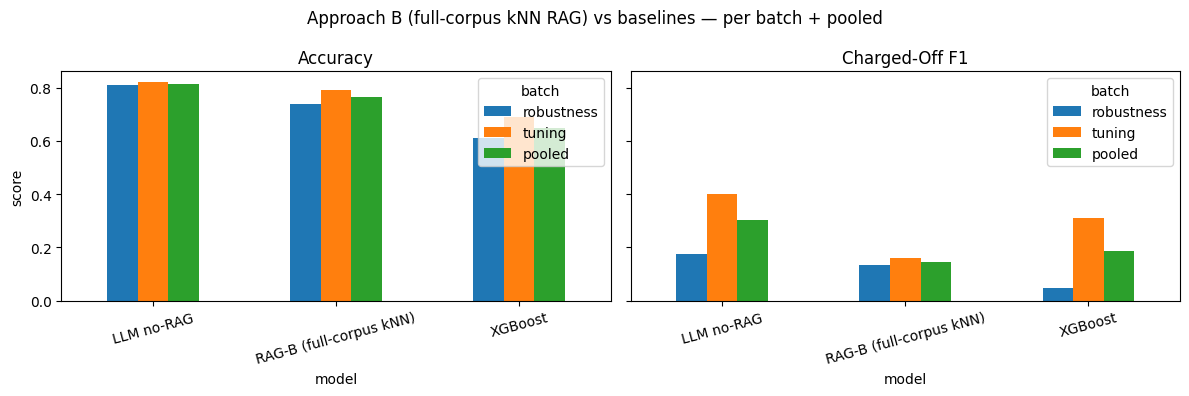

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, metric, title in zip(axes, ['accuracy', 'f1_charged_off'], ['Accuracy', 'Charged-Off F1']):
    (summary.pivot(index='model', columns='batch', values=metric)
            [['robustness', 'tuning', 'pooled']]
            .plot.bar(ax=ax, rot=15))
    ax.set_title(title); ax.set_ylabel('score')
fig.suptitle('Approach B (full-corpus kNN RAG) vs baselines — per batch + pooled')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/05b_comparison.png', dpi=150, bbox_inches='tight'); plt.show()